<a href="https://colab.research.google.com/github/NAghayefa/Interview-Tasks/blob/main/Leaply.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task1 (AB Testing)
On a project where a user purchases in-game currency for real money, the design team proposed to change the
appearance of the payment screen for mobile devices to increase the number of payments. The new option was
implemented on a group of users starting on July 24 at 0000, leaving the basic option for some users. Based on
the data on payments made, answer the following question:

**Question:** Should the innovation be implemented for everyone or should it be rejected?

Justify your conclusions with graphs and calculations.

Data Dictionary:
1. id_user - user identifier
2. gender - user gender
3. date_reg - user registration date and time
4. platform - user platform
5. id_traffic_source - advertising platform from which the user came
6. country_group - country group
7. age_group - age group
8. system - device operating system
9. date_payment - date and time of payment
10. method - payment method
11. amount - payment amount
12. successful_payment - 1, if the payment is successful
13. split_group - test group marker. If 1 - user from the test group

#Steps
1. Load and explore the data
2. Check for data integrity (duplicates, nulls)
3. Filter: mobile platform + payments from July 24 onward (experiment start)
4. Aggregate to user-level: did the user complete at least one successful payment?
5. Calculate Conversion Rate per split group
6. Statistical tests (Chi-square, Z-test, 95% CI) to assess significance
7. Visualize results


In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.stats.api as sms
from scipy.stats import chi2_contingency, norm


In [88]:
df = pd.read_csv('/content/raw_data.csv')

In [89]:
df['date_reg'] = pd.to_datetime(df['date_reg'])
df['date_payment'] = pd.to_datetime(df['date_payment'])

In [90]:
df.shape  #we have 58938 rows and 13 columns

(58938, 13)

In [91]:
df.groupby('id_user')['split_group'].nunique().value_counts()
#checking duplicates, each user must be in one group

,count
split_group,
1,50732


In [92]:
df.info()
#Nulls in date_payment are expected these are registered users who have not attempted a payment.
#Columns like method, successful_payment are also null for those users.
#However, 'amount' has 10122 non-null values vs 10238 for date_payment.
#The 116-row gap needs investigation likely failed payments where amount was not recorded.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58938 entries, 0 to 58937
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_user             58938 non-null  object        
 1   gender              58938 non-null  object        
 2   date_reg            58938 non-null  datetime64[ns]
 3   platform            58938 non-null  object        
 4   id_traffic_source   58938 non-null  object        
 5   country_group       58938 non-null  int64         
 6   age_group           58938 non-null  int64         
 7   system              58938 non-null  object        
 8   date_payment        10238 non-null  datetime64[ns]
 9   method              10238 non-null  object        
 10  amount              10122 non-null  float64       
 11  successful_payment  10238 non-null  float64       
 12  split_group         58938 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(3), ob

In [93]:
#Actually I checked it in Excel and I'm right but let's do it in Python too)
#Is there user that has successful payment = 1 but amount is null?
print(df[df['successful_payment'] == 1]['amount'].isna().sum())

#Is there user that has successful payment = 0 but amount is null?
print(df[df['successful_payment'] == 0]['amount'].isna().sum())

#Both of them togther
print(df.groupby('successful_payment')['amount'].apply(lambda x: x.isna().sum()))

0
116
successful_payment
0.0    116
1.0      0
Name: amount, dtype: int64


So everything is fine. Keep going

In [94]:
df.value_counts('split_group')

,count
split_group,
0,49255
1,9683


In [95]:
df.value_counts('platform')

,count
platform,
mobile,46619
desktop,8649
other,3670


In [96]:
df.value_counts('date_reg')

,count
date_reg,
2021-07-08 17:46:42,251
2021-07-21 07:13:43,214
2021-07-13 17:21:55,175
2021-06-26 23:16:36,165
2021-06-28 03:34:22,156
...,...
2021-07-05 04:57:47,1
2021-07-05 04:59:01,1
2021-07-05 04:59:15,1


In [97]:
df.value_counts('successful_payment')

,count
successful_payment,
1.0,6809
0.0,3429


Everything is fine

# Filter Decision: date_payment vs date_reg?

Users who registered on or after July 24 were assigned to the experiment.

In [98]:
#Now we filter them: mobile platform only, payments on or after July 24 (reg date)
mobile_exp = df[
    (df['platform'] == 'mobile') &
    (df['date_reg'] >= '2021-07-24')
]

print("Unique users:", mobile_exp['id_user'].nunique())
print(mobile_exp['split_group'].value_counts())

Unique users: 11792
split_group
0    6731
1    6633
Name: count, dtype: int64


In [99]:
#Aggregate to user level
#User is 'converted' if they made at least one successful payment
#we use max() on successful_payment: if any payment = 1.0, the user converted

#Important Note: The number of unique users is lower than total rows .
#This means many users attempted multiple payments.
#We intentionally take max() — if a user succeeded even once, they count as converted.
#Taking the last payment instead could undercount conversions (a user might retry
#after a failed attempt and succeed).
user_level = mobile_exp.groupby(['id_user', 'split_group']).agg(
    converted=('successful_payment', lambda x: 1 if x.max() == 1.0 else 0)
).reset_index()
user_level

,id_user,split_group,converted
0,000205a296bffbae6f5699ba14ed48c1e961fb0b1c22f3...,1,0
1,000a3cce1ebd0d227f1694d60e97e279839701fe387f81...,1,0
2,000ac4856b089465071ef9a9df3009ae0b485bd96dd185...,1,0
3,000f7f5979ff8fe5d0d4ed206c5129ef9969f5dcb7c8a1...,1,0
4,0015ace20afb384aa8f702459cf192b10d132921ad371b...,0,0
...,...,...,...
11787,fff51acea3718eac8997737566c41803aa6284e9461ffa...,0,0
11788,fff5dc6bda47f78c73212d694bccc12bdd1a23e796f3ff...,0,0
11789,ffff2b5891f898ac31cba106a22e11d3d505dc3b9adca9...,0,0
11790,ffff81a9feaf249f78fde9146b37a5b18cf85f9dd7401d...,0,0


In [100]:
#converstion rates according to split groups
total_per_group = mobile_exp.groupby('split_group')['id_user'].nunique()
converted_per_group = user_level.groupby('split_group')['converted'].sum()

summary = pd.DataFrame({
    'conversions': converted_per_group,
    'total': total_per_group
})
summary['CR%'] = (summary['conversions'] / summary['total'] * 100).round(2)
print(summary)


             conversions  total   CR%
split_group                          
0                    171   5877  2.91
1                    171   5915  2.89


In [101]:
#recording each of them separatly
n0 = summary.loc[0, 'total'];    n1 = summary.loc[1, 'total']
c0 = summary.loc[0, 'conversions']; c1 = summary.loc[1, 'conversions']
cr0 = summary.loc[0, 'CR%'] / 100; cr1 = summary.loc[1, 'CR%'] / 100

## Statistical Testing
The conversion rates look similar. But we need to determine:
**Is the difference statistically significant, or could it be due to random chance?**

We will run:
- **Chi-square test**: compares observed frequencies between groups
- **Z-test**: measures how many standard deviations the difference is from zero
- **95% Confidence Interval**: shows the plausible range of the true difference

If p-value > 0.05 → the difference is not statistically significant (could be chance).

In [102]:
#Chi-square
contingency  = [[c0, n0-c0], [c1, n1-c1]]
chi2, p_chi2, dof, _ = chi2_contingency(contingency)
print(f"Chi2={chi2:.4f},  p={p_chi2:.4f}")

Chi2=0.0000,  p=0.9955


**Chi-square result**: p > 0.05 → the difference between groups is **not statistically significant**.
We cannot reject the null hypothesis. The observed difference is likely due to random chance.

Next, we confirm with a Z-test to see how far the difference is from zero in standard deviation units.

In [103]:
p_pool = (c0+c1) / (n0+n1)
se     = np.sqrt(p_pool*(1-p_pool) * (1/n0+1/n1))
z_stat = (cr1-cr0) / se
p_z    = 2*(1 - norm.cdf(abs(z_stat)))
print(f"Z={z_stat:.4f},  p={p_z:.4f}")

Z=-0.0647,  p=0.9484


**Z-test result**: The z-statistic is close to zero, confirming the two groups are nearly identical.
p > 0.05 → not significant.

Finally, let's compute the 95% Confidence Interval to understand the range of the true difference.

In [104]:
se_diff = np.sqrt(cr0*(1-cr0)/n0 + cr1*(1-cr1)/n1)
ci_low  = (cr1-cr0) - 1.96*se_diff
ci_high = (cr1-cr0) + 1.96*se_diff
print(f"95% CI: [{ci_low*100:.3f}%,  {ci_high*100:.3f}%]")

95% CI: [-0.626%,  0.586%]


**95% CI result**: The confidence interval straddles zero — it includes both negative and positive values.
This means the new design could make things **worse or better**, but we cannot be confident it helps.
From a business perspective, there is no justification to roll out the new design.

## Visualizations
Lastly lets show everything with graphics to make everything more clrea for our decision.

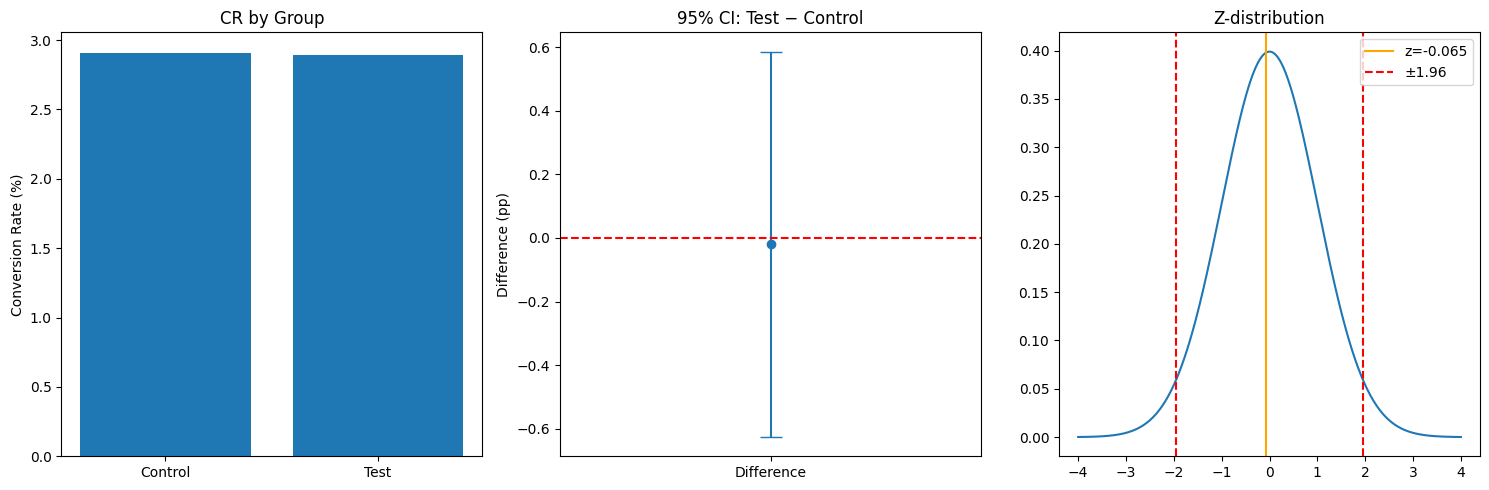

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

#bar chart
axes[0].bar(['Control','Test'], [cr0*100, cr1*100])
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('CR by Group')

#CI plot
axes[1].errorbar(['Difference'], [(cr1-cr0)*100],
                 yerr=[[abs(ci_low*100 - (cr1-cr0)*100)],
                       [abs(ci_high*100 - (cr1-cr0)*100)]],
                 fmt='o', capsize=8)
axes[1].axhline(0, linestyle='--', color='red')
axes[1].set_title('95% CI: Test − Control')
axes[1].set_ylabel('Difference (pp)')

#Z-distribution
x = np.linspace(-4,4,500)
axes[2].plot(x, norm.pdf(x))
axes[2].axvline(z_stat, color='orange', label=f'z={z_stat:.3f}')
axes[2].axvline(-1.96, color='red', linestyle='--', label='±1.96')
axes[2].axvline( 1.96, color='red', linestyle='--')
axes[2].set_title('Z-distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

In [106]:
print(summary)
print(f"Difference: {(cr1-cr0)*100:.2f} pp")
print(f"Chi2 p-value: {p_chi2:.4f}")
print(f"Z-test p-value: {p_z:.4f}")
print(f"95% CI: [{ci_low*100:.3f}%, {ci_high*100:.3f}%]")

             conversions  total   CR%
split_group                          
0                    171   5877  2.91
1                    171   5915  2.89
Difference: -0.02 pp
Chi2 p-value: 0.9955
Z-test p-value: 0.9484
95% CI: [-0.626%, 0.586%]


## Final Decision: **Reject the new design**

| Metric | Control (Old Design) | Test (New Design) |
|---|---|---|
| Users | 5,877 | 5,915 |
| Conversions | 171 | 171 |
| Conversion Rate | 2.91% | 2.89% |
| Difference | — | -0.02 pp |

**Statistical Evidence:**
- Chi-square p-value = 0.9955 → not significant (> 0.05)
- Z-test p-value = 0.9484 → not significant (> 0.05)
- 95% CI: [-0.626%, 0.586%] → includes zero, no reliable positive effect

**Conclusion**: The new payment screen design does **not** statistically improve conversion rates.
The difference observed is consistent with random variation.
The innovation should **not** be rolled out to all users.